In [1]:
# Importamos las librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Figuras geométricas y texto

En esta sección vamos a aprender a dibujar lineas, círculos, puntos, rectángulos (vacíos o rellenos) y a agregar texto a las imágenes.

Lo vamos a hacer sobre un fondo negro para entender mejor. Luego podrán aplicar estas técnicas sobre imagenes concretas (por ejemplo, usando rectángulos para encuadrar objetos o puntos para identificar alguna posición)

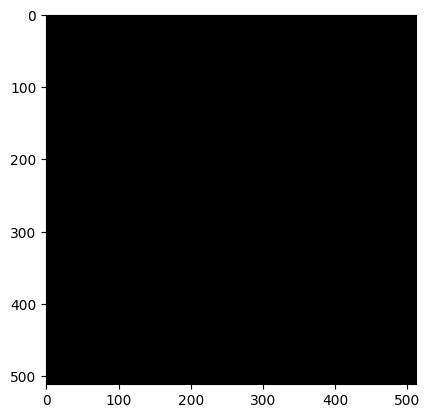

In [2]:
# Tapiz negro RGB de 512x512
img = np.zeros((512, 512, 3), np.uint8) #512 alto,512 ancho,3 canales #np.zerospara hacer una matriz llena de ceros (por eso es de color negro)
plt.imshow(img, cmap='gray');

** Linea**

Para agregar una linea recta usamos `cv2.line()` con los siguientes parametros:
* img: la imagen a la que agregaremos la linea
* pt1: una tupla con las coordenadas en pixeles de donde empieza la linea. Por ejemplo: (0, 0)
* pt2: una tupla con las coordenadas en pixeles de donde termina la linea. Por ejemplo: (10, 50)
* color: una tupla con el color (r, g, b)
* thickness: el ancho de la linea

En este ejemplo, trazamos una linea verde desde la esquina superior izquierda (0,0) al punto (300, 300)

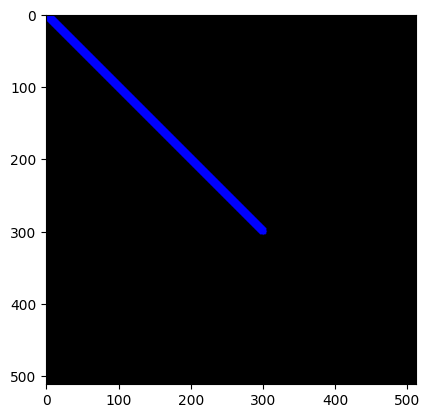

In [3]:
cv2.line(img, pt1=(0, 0), pt2=(300, 300), color=(0, 0, 255), thickness=10)
plt.imshow(img);

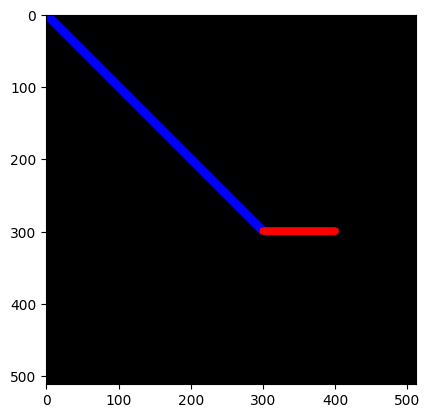

In [4]:
# Acá creamos una linea roja horizontal de 100 pixeles desde el vertice de la linea anterior
# Esta es 2 veces más ancha que la verde
cv2.line(img, pt1=(300, 300), pt2=(400, 300), color=(255, 0, 0), thickness=10)
plt.imshow(img);

**Rectángulo**

Para agregar un rectángulo usamos `cv2.rectangle()` con los mismos parametros que usa `cv2.line`. Los dos puntos elegidos, en lugar de definir una linea, van a usarse como dos esquinas del rectángulo:

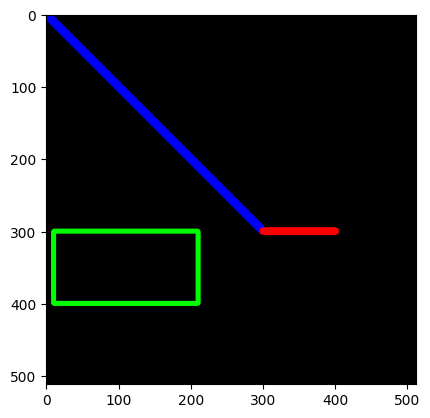

In [5]:
cv2.rectangle(img, (10, 300), (210, 400), (0, 255, 0), 5)
plt.imshow(img);

**Rectángulo relleno**

Para que esté relleno a "thickness" le pasamos de parametro `cv2.FILLED`

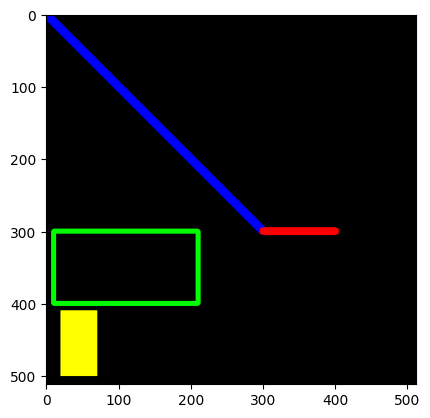

In [6]:
cv2.rectangle(img, (20, 410), (70, 500), (255, 255, 0), cv2.FILLED)
plt.imshow(img);

**Círculo**

Para agregar un círculo usamos `cv2.circle` con parámetros:
* img: la imagen a la que agregaremos la linea
* center: tupla con las coordenadas en pixeles de el centro del círculo
* radius: longitud en pixeles del radio del círculo
* color: una tupla con el color (r, g, b)
* thickness: el ancho de la linea

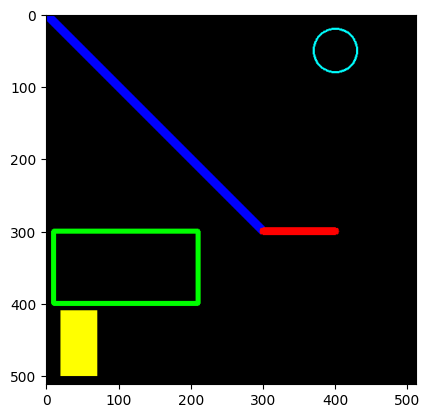

In [7]:
cv2.circle(img, center=(400, 50), radius=30, color=(0, 255, 255), thickness=2)
plt.imshow(img);

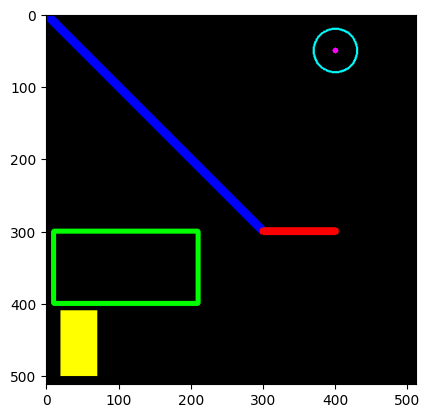

In [8]:
# Un circulo de radio 1 es un punto
cv2.circle(img, center=(400, 50), radius=1, color=(255, 0, 255), thickness=5)
plt.imshow(img);

**Texto**
Para agregar texto usamos `cv2.putText()`.

* img: la imagen a la que agregaremos la linea
* text: el texto a agregar
* org: un punto. especifica la esquina inferior izquierda del texto
* fuente: una de las opciones bajo `cv2.FONT_...`
* tamaño de fuente: 1 es un tamaño razonable, puede ser inferior a 1 para tamaños más chicos
* color: una tupla con el color (r, g, b)
* thickness: el ancho de la linea

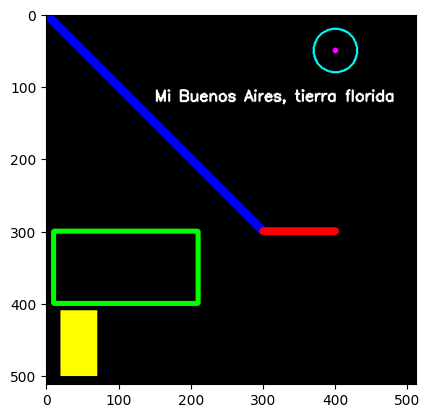

In [9]:
cv2.putText(img, "Mi Buenos Aires, tierra florida", (150, 120),  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
plt.imshow(img);

##Recreacion en una linea

Yo quise crear una circunferencia que en su diametro contuviera otra figura, por ejemplo un rectangulo de forma tal que con solo adaptar el radio de la circunferencia, el tamaño de la figura inscripta se ajuste automaticamente.
Ademas agregué texto dentro de la figura, de forma que tambien quede centrado, independientemente del tamaño. Logicamente si la circunferencia es muy pequeña, todo estará desbordado. Si la circunferencia es grande, todo estará contenido.

### 📐 Relación geométrica: cuadrado inscripto en una circunferencia

Queremos inscribir un cuadrado dentro de una circunferencia de radio \( r \), de forma que:

- el cuadrado quede completamente contenido
- y tenga el mayor tamaño posible

---

### 🔷 Idea clave

La mayor distancia que puede existir dentro de una circunferencia es su diámetro:

$$
\text{diámetro} = 2r
$$

En un cuadrado, la mayor distancia entre dos puntos es su diagonal.

Para que el cuadrado esté completamente contenido en la circunferencia, su diagonal debe coincidir con el diámetro:

$$
\text{diagonal del cuadrado} = 2r
$$

---

### 🔷 Relación en el cuadrado

Sabemos que la diagonal de un cuadrado está dada por:

$$
\text{diagonal} = \text{lado} \cdot \sqrt{2}
$$

---

### 🔷 Igualando ambas expresiones

$$
\text{lado} \cdot \sqrt{2} = 2r
$$

---

### 🔷 Despejando el lado

$$
\text{lado} = \frac{2r}{\sqrt{2}} = r \cdot \sqrt{2}
$$

---

### 🎯 Conclusión

El lado del cuadrado queda determinado por el radio de la circunferencia:

$$
\text{lado} = r \cdot \sqrt{2}
$$

Esto garantiza que:

- los vértices del cuadrado tocan la circunferencia  
- el cuadrado es el máximo posible dentro del círculo  
- toda la figura queda definida en función del radio  

---

💥 Por eso en el código aparece:

```python
lado = radio * np.sqrt(2)

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

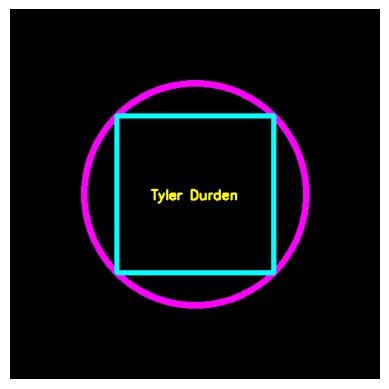

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear imagen negra 500x500
img = np.zeros((500, 500, 3), np.uint8)

# 2. Dibujar círculo (centro (250,250), radio 5)
centro = (250, 250)
radio = 150  # aumento el radio para que se vea bien y entre el cuadrado
cv2.circle(img, centro, radio, (255, 0, 255), 7)

# 3. Calcular el cuadrado INSCRIPTO dentro del círculo
lado = int(radio * np.sqrt(2))  # lado máximo dentro de la circunferencia
mitad = lado // 2

pt1 = (centro[0] - mitad, centro[1] - mitad)
pt2 = (centro[0] + mitad, centro[1] + mitad)

# Dibujar cuadrado
cv2.rectangle(img, pt1, pt2, (255, 255, 0), 6)

texto = "Tyler Durden"
font = cv2.FONT_HERSHEY_SIMPLEX
escala = 0.6
grosor = 2

# Tamaño del texto
(tamano_texto, _) = cv2.getTextSize(texto, font, escala, grosor)
ancho_texto, alto_texto = tamano_texto

# Centro del cuadrado
centro_x = (pt1[0] + pt2[0]) // 2
centro_y = (pt1[1] + pt2[1]) // 2

# Posición centrada
pos_x = centro_x - (ancho_texto // 2)
pos_y = centro_y + (alto_texto // 2)

# Dibujar texto
cv2.putText(img, texto, (pos_x, pos_y), font, escala, (0, 255, 255), grosor)

# Mostrar
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

##V2

Aqui simplemente quise darle un poco de animacion para mostrar que el cuadrado esta contenido en la circunferencia, por eso agregue una rotacion continua.

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Imagen base
alto, ancho = 500, 500
centro = np.array([250, 250])
radio = 80

# Lado del cuadrado inscripto en la circunferencia
lado = int(radio * np.sqrt(2))
mitad = lado / 2

# Vértices del cuadrado centrado en (0,0)
cuadrado_base = np.array([
    [-mitad, -mitad],
    [ mitad, -mitad],
    [ mitad,  mitad],
    [-mitad,  mitad]
], dtype=np.float32)

texto = "Tyler Durden"
font = cv2.FONT_HERSHEY_SIMPLEX
escala = 0.55
grosor = 2

fig, ax = plt.subplots(figsize=(6, 6))

def rotar_puntos(puntos, angulo_grados):
    ang = np.radians(angulo_grados)
    R = np.array([
        [np.cos(ang), -np.sin(ang)],
        [np.sin(ang),  np.cos(ang)]
    ])
    return puntos @ R.T

def actualizar(frame):
    ax.clear()

    # Fondo negro
    img = np.zeros((alto, ancho, 3), dtype=np.uint8)

    # Círculo fucsia
    cv2.circle(img, tuple(centro.astype(int)), radio, (255, 0, 255), 7)

    # Rotar cuadrado
    cuadrado_rotado = rotar_puntos(cuadrado_base, frame)
    vertices = cuadrado_rotado + centro
    vertices_int = vertices.astype(np.int32).reshape((-1, 1, 2))

    # Dibujar cuadrado turquesa
    cv2.polylines(img, [vertices_int], isClosed=True, color=(255, 255, 0), thickness=6)

    # Texto centrado
    (tam_texto, _) = cv2.getTextSize(texto, font, escala, grosor)
    ancho_texto, alto_texto = tam_texto
    pos_x = int(centro[0] - ancho_texto / 2)
    pos_y = int(centro[1] + alto_texto / 2)

    # Texto amarillo
    cv2.putText(img, texto, (pos_x, pos_y), font, escala, (0, 255, 255), grosor)

    # Mostrar
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis("off")

ani = FuncAnimation(fig, actualizar, frames=np.arange(0, 360, 5), interval=100)
plt.close(fig)

HTML(ani.to_jshtml())